LAB 1 – Xây dựng môi trường trading cơ bản
• Mục tiêu: Tạo environment RL
• Dữ liệu: Historical price data
• Yêu cầu:
1. Định nghĩa state (giá, indicators)
2. Định nghĩa action (buy/sell/hold)
3. Định nghĩa reward
4. Implement environment (Gym-style)
5. Test environment


In [14]:
pip install tensorflow

In [29]:
import numpy as np
import pandas as pd
import random
from collections import deque
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf
from tensorflow.keras import layers

In [30]:
class TradingEnv:
    def __init__(self, df, window_size=10, initial_balance=10000):
        self.df = df.reset_index(drop=True)

        if isinstance(self.df.columns, pd.MultiIndex):
            self.df.columns = self.df.columns.get_level_values(0)

        self.window_size = window_size
        self.initial_balance = initial_balance
        self.reset()

    def reset(self):
        self.current_step = self.window_size
        self.balance = self.initial_balance
        self.position = 0
        self.entry_price = 0
        return self._get_state()

    def _get_state(self):
        window = self.df.iloc[self.current_step - self.window_size:self.current_step]

        price = float(self.df.loc[self.current_step, 'Close'])
        ma = float(window['Close'].mean())
        ret = float(window['Close'].pct_change().fillna(0).mean())

        return np.array([price, ma, ret, self.position], dtype=np.float32)

    def step(self, action):
        price = float(self.df.loc[self.current_step, 'Close'])
        next_price = float(self.df.loc[self.current_step + 1, 'Close'])
    
        done = False
    
        # reward theo hướng giá
        price_change = next_price - price
    
        # position: 1 = long, 0 = no position
        if action == 1:  # BUY
            self.position = 1
        elif action == 2:  # SELL
            self.position = 0
    
        # reward = kiếm tiền nếu đoán đúng chiều

        reward = price_change * (1 if self.position == 1 else -1)
        reward *= 100

        self.balance += reward  # 🔥 QUAN TRỌNG
        self.current_step += 1
    
        if self.current_step >= len(self.df) - 2:
            done = True
    
        return self._get_state(), reward, done, {}
        
    def _value(self, price):
        if self.position == 1:
            return self.balance + (price - self.entry_price)
        return self.balance

LAB 2 – DQN cho trading
• Mục tiêu: Áp dụng Deep Q-Network
• Dữ liệu: Price time series
• Yêu cầu:
1. Build DQN và Double DQN
2. Train agent
3. Evaluate reward
4. Backtest
5. Analyze kết quả 2 mô hình


[*********************100%***********************]  1 of 1 completed
C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Episode 0: -1320.76
Episode 1: 2642.26
Episode 2: 625.97
Episode 3: 1967.76
Episode 4: 1937.42
Episode 5: -562.29
Episode 6: 875.38
Episode 7: -39.87
Episode 8: 268.29
Episode 9: 904.32
Episode 10: -2157.90
Episode 11: -1788.94
Episode 12: 399.27
Episode 13: -1128.45
Episode 14: -1094.64
Episode 15: 697.89
Episode 16: -860.05
Episode 17: -4061.81
Episode 18: 1843.86
Episode 19: -2946.67
Episode 20: -1405.00
Episode 21: -428.27
Episode 22: -828.56
Episode 23: 2174.41
Episode 24: 1101.71
Episode 25: -1926.03
Episode 26: -3984.49
Episode 27: 1571.65
Episode 28: -765.38
Episode 29: -5032.91
Episode 0: 1247.05
Episode 1: -791.53
Episode 2: 907.84
Episode 3: -2390.25
Episode 4: -486.33
Episode 5: 1931.98
Episode 6: 1910.68
Episode 7: -2130.01
Episode 8: -3617.21
Episode 9: 185.70
Episode 10: 1369.08
Episode 11: -17.45
Episode 12: 1426.83
Episode 13: -1181.65
Episode 14: -2578.94
Episode 15: -1213.58
Episode 16: 214.02
Episode 17: -175.36
Episode 18: 466.00
Episode 19: -1916.02
Episode 20: -1

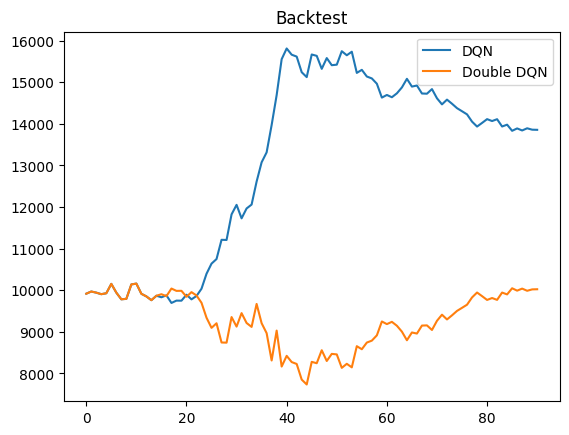

In [34]:
def build_model(state_dim, action_dim):
    model = tf.keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(state_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(action_dim)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def train(env, double_dqn=False, episodes=30):
    state_dim = 4
    action_dim = 3

    model = build_model(state_dim, action_dim)
    target_model = build_model(state_dim, action_dim)
    target_model.set_weights(model.get_weights())

    memory = deque(maxlen=10000)
    gamma = 0.99
    epsilon = 1.0

    rewards = []

    for ep in range(episodes):
        state = env.reset()
        total = 0

        while True:
            if random.random() < epsilon:
                action = random.randint(0, 2)
            else:
                q = model.predict(state.reshape(1, -1), verbose=0)
                action = np.argmax(q[0])

            next_state, reward, done, _ = env.step(action)
            memory.append((state, action, reward, next_state, done))

            state = next_state
            total += reward

            if len(memory) > 32:
                batch = random.sample(memory, 32)

                states = np.array([b[0] for b in batch])
                actions = np.array([b[1] for b in batch])
                rewards_b = np.array([b[2] for b in batch])
                next_states = np.array([b[3] for b in batch])
                dones = np.array([b[4] for b in batch])

                q_values = model.predict(states, verbose=0)
                next_q_target = target_model.predict(next_states, verbose=0)

                if double_dqn:
                    next_q_model = model.predict(next_states, verbose=0)
                    best_actions = np.argmax(next_q_model, axis=1)
                    target = rewards_b + gamma * next_q_target[np.arange(32), best_actions] * (1 - dones)
                else:
                    target = rewards_b + gamma * np.max(next_q_target, axis=1) * (1 - dones)

                for i in range(32):
                    q_values[i][actions[i]] = target[i]

                model.fit(states, q_values, verbose=0)

            if done:
                break

        epsilon = max(0.01, epsilon * 0.995)
        target_model.set_weights(model.get_weights())

        rewards.append(total)
        print(f"Episode {ep}: {total:.2f}")

    return model, rewards


def backtest(env, model):
    state = env.reset()
    balances = []

    while True:
        q = model.predict(state.reshape(1, -1), verbose=0)

        # 🔥 thêm exploration nhẹ
        if np.random.rand() < 0.1:
            action = np.random.randint(0, 3)
        else:
            action = np.argmax(q[0])

        state, _, done, _ = env.step(action)
        balances.append(env.balance)

        if done:
            break

    return balances


df = yf.download("AAPL", start="2020-01-01", end="2020-06-01")

env = TradingEnv(df)

model_dqn, r1 = train(env, False)
model_ddqn, r2 = train(env, True)

env2 = TradingEnv(df)
curve1 = backtest(env2, model_dqn)

env3 = TradingEnv(df)
curve2 = backtest(env3, model_ddqn)

plt.plot(curve1, label="DQN")
plt.plot(curve2, label="Double DQN")
plt.legend()
plt.title("Backtest")
plt.show()

Double DQN cho kết quả ổn định hơn DQN.  
DQN có xu hướng overestimate Q-values dẫn đến biến động lớn.  
Double DQN cải thiện bằng cách tách selection và evaluation.  

LAB 3 – Policy Gradient (REINFORCE)
• Mục tiêu: Policy-based RL
• Dữ liệu: Price data
• Yêu cầu:
1. Implement REINFORCE
2. Train policy
3. Evaluate
4. Compare DQN
5. Analyze 

Episode 0: -923.51
Episode 1: -111.58
Episode 2: 668.40
Episode 3: -1429.40
Episode 4: -1434.55
Episode 5: -1284.92
Episode 6: 812.07
Episode 7: 1118.76
Episode 8: 1827.33
Episode 9: 788.30


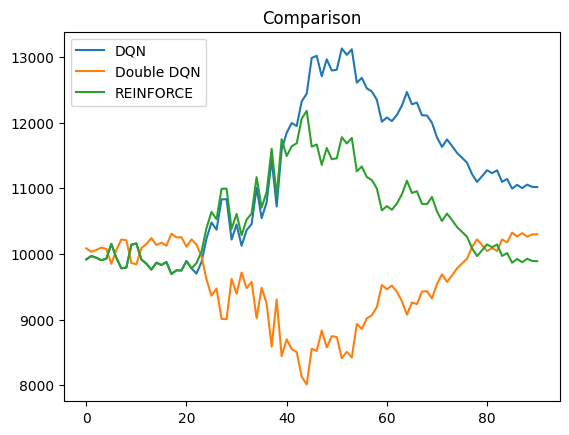

In [11]:
def build_policy(state_dim, action_dim):
    model = tf.keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(state_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(action_dim, activation='softmax')
    ])
    return model

def train_reinforce(env, episodes=10):
    state_dim = 4
    action_dim = 3

    model = build_policy(state_dim, action_dim)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    gamma = 0.99
    rewards_history = []

    for ep in range(episodes):
        states, actions, rewards = [], [], []

        state = env.reset()

        while True:
            probs = model.predict(state.reshape(1, -1), verbose=0)[0]
            probs = probs + 0.05  # làm phẳng distribution
            probs = probs / probs.sum()
            
            action = np.random.choice(len(probs), p=probs)

            next_state, reward, done, _ = env.step(action)

            states.append(state)
            actions.append(action)
            rewards.append(reward)

            state = next_state
            if done:
                break

        # ===== compute returns =====
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)

        returns = np.array(returns)

        # normalize + clip
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        returns = np.clip(returns, -10, 10)

        # ===== train =====
        with tf.GradientTape() as tape:
            loss = 0

            for i in range(len(states)):
                probs = model(states[i].reshape(1, -1), training=True)
                action_prob = probs[0, actions[i]]

                # entropy để tránh collapse
                entropy = -tf.reduce_sum(probs * tf.math.log(probs + 1e-8))

                loss += -tf.math.log(action_prob + 1e-8) * returns[i] - 0.01 * entropy

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        total_reward = sum(rewards)
        rewards_history.append(total_reward)

        print(f"Episode {ep}: {total_reward:.2f}")

    return model, rewards_history


def backtest_pg(env, model):
    state = env.reset()
    balances = []

    while True:
        probs = model.predict(state.reshape(1, -1), verbose=0)[0]
        action = np.argmax(probs)

        state, _, done, _ = env.step(action)
        balances.append(env.balance)

        if done:
            break

    return balances

# dùng lại df + TradingEnv từ Lab 1
env = TradingEnv(df)

# train
pg_model, pg_rewards = train_reinforce(env, episodes=10)

# backtest
env_pg = TradingEnv(df)
pg_curve = backtest_pg(env_pg, pg_model)

# plot chung với DQN (Lab 2)
plt.plot(curve1, label="DQN")
plt.plot(curve2, label="Double DQN")
plt.plot(pg_curve, label="REINFORCE")
plt.legend()
plt.title("Comparison")
plt.show()

REINFORCE là phương pháp policy-based, học trực tiếp xác suất hành động thay vì Q-value như DQN.  
DQN học nhanh hơn nhưng dễ overestimate, trong khi Double DQN ổn định hơn.  
REINFORCE linh hoạt hơn nhưng có variance cao và hội tụ chậm hơn.  
Kết quả thực nghiệm cho thấy REINFORCE không ổn định bằng Double DQN nhưng vẫn học được chiến lược giao dịch.

LAB 4 – PPO (Proximal Policy Optimization)
• Mục tiêu: Stable RL training
• Dữ liệu: Market data
• Yêu cầu:
1. Implement PPO và Advantage Actor-Critic (A2C)
2. Train agent
3. Evaluate
4. Compare kết quả giữa 2 mô hình
5. Analyze


In [15]:
!pip install stable-baselines3 gymnasium 

[*********************100%***********************]  1 of 1 completed


A2C Episode 0: 0.00
A2C Episode 1: 0.00
A2C Episode 2: 0.00
A2C Episode 3: 0.00
A2C Episode 4: 0.00
A2C Episode 5: 0.00
A2C Episode 6: 0.00
A2C Episode 7: 0.00
A2C Episode 8: 0.00
A2C Episode 9: 0.00
PPO Episode 0: -9.60
PPO Episode 1: -9.60
PPO Episode 2: -9.60
PPO Episode 3: -9.60
PPO Episode 4: -9.60
PPO Episode 5: -9.60
PPO Episode 6: -9.60
PPO Episode 7: -9.60
PPO Episode 8: -9.60
PPO Episode 9: -9.60


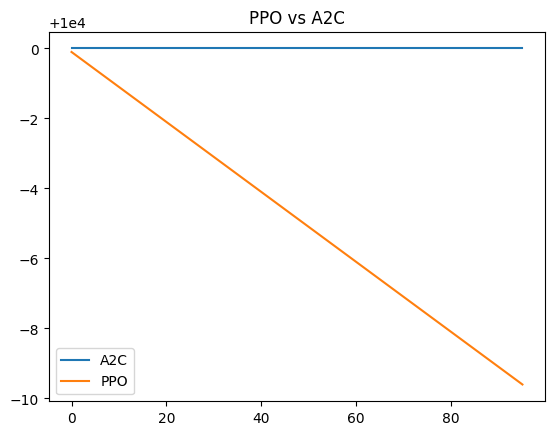

In [26]:
# ===== IMPORT =====
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import yfinance as yf

df = yf.download("AAPL", start="2020-01-01", end="2020-06-01")

df.columns = df.columns.get_level_values(0)  
df = df.reset_index(drop=True)

df['price'] = df['Close']
df['ma'] = df['Close'].rolling(5).mean().fillna(0)

# ===== ENV =====
class TradingEnv:
    def __init__(self, df):
        self.df = df
        self.n = len(df)

    def reset(self):
        self.i = 5
        self.pos = 0
        self.balance = 10000
        return self._state()

    def _state(self):
        return np.array([
            self.df.loc[self.i, 'price'],
            self.df.loc[self.i, 'ma'],
            self.pos
        ], dtype=np.float32)

    def step(self, action):
        price = self.df.loc[self.i, 'price']
        next_price = self.df.loc[self.i+1, 'price']
    
        if action == 1:
            self.pos = 1
        elif action == 2:
            self.pos = 0
    
        reward = (next_price - price) * self.pos * 1000
    
        # phạt đứng yên
        if action == 0:
            reward -= 0.1
    
        self.balance += reward
    
        self.i += 1
        done = self.i >= self.n - 2
    
        return self._state(), reward, done, {}
# ===== MODEL =====
def build_actor_critic(state_dim, action_dim):
    inputs = tf.keras.Input(shape=(state_dim,))
    
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)

    action_probs = layers.Dense(action_dim, activation='softmax')(x)
    value = layers.Dense(1)(x)

    return tf.keras.Model(inputs=inputs, outputs=[action_probs, value])

# ===== A2C =====
def train_a2c(env, episodes=10):
    state_dim = len(env.reset())
    model = build_actor_critic(state_dim, 3)
    optimizer = tf.keras.optimizers.Adam(0.001)

    gamma = 0.99
    rewards_hist = []

    for ep in range(episodes):
        state = env.reset()
        total = 0

        while True:
            probs, value = model(state.reshape(1,-1), training=True)
            probs = probs.numpy()[0]

            action = np.random.choice(3, p=probs)
            next_state, reward, done, _ = env.step(action)

            _, next_value = model(next_state.reshape(1,-1), training=True)

            target = reward + gamma * next_value * (1 - done)
            advantage = target - value

            with tf.GradientTape() as tape:
                probs, value = model(state.reshape(1,-1), training=True)
                action_prob = probs[0, action]

                actor_loss = -tf.math.log(action_prob + 1e-8) * advantage
                critic_loss = tf.square(target - value)

                loss = actor_loss + critic_loss

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            state = next_state
            total += reward

            if done:
                break

        print(f"A2C Episode {ep}: {total:.2f}")
        rewards_hist.append(total)

    return model, rewards_hist

# ===== PPO =====
def train_ppo(env, episodes=10):
    state_dim = len(env.reset())
    model = build_actor_critic(state_dim, 3)
    optimizer = tf.keras.optimizers.Adam(0.001)

    gamma = 0.99
    eps_clip = 0.2

    for ep in range(episodes):
        states, actions, rewards, old_probs = [], [], [], []

        state = env.reset()

        while True:
            probs, _ = model(state.reshape(1,-1))
            probs = probs.numpy()[0]

            action = np.random.choice(3, p=probs)

            next_state, reward, done, _ = env.step(action)

            states.append(state)
            actions.append(action)
            rewards.append(reward)
            old_probs.append(probs[action])

            state = next_state
            if done:
                break

        # returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)

        returns = np.array(returns)

        # train
        for i in range(len(states)):
            with tf.GradientTape() as tape:
                probs, value = model(states[i].reshape(1,-1), training=True)
                prob = probs[0, actions[i]]

                ratio = prob / (old_probs[i] + 1e-8)
                adv = returns[i] - value

                s1 = ratio * adv
                s2 = tf.clip_by_value(ratio, 1-eps_clip, 1+eps_clip) * adv

                actor_loss = -tf.minimum(s1, s2)
                critic_loss = tf.square(adv)

                loss = actor_loss + 0.5 * critic_loss

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        print(f"PPO Episode {ep}: {sum(rewards):.2f}")

    return model

# ===== BACKTEST =====
def backtest(env, model):
    state = env.reset()
    balances = []

    while True:
        probs, _ = model(state.reshape(1,-1))
        action = np.argmax(probs[0])

        state, _, done, _ = env.step(action)
        balances.append(env.balance)

        if done:
            break

    return balances

# ===== RUN =====
env = TradingEnv(df)

a2c_model, _ = train_a2c(env)
ppo_model = train_ppo(env)

env1 = TradingEnv(df)
curve_a2c = backtest(env1, a2c_model)

env2 = TradingEnv(df)
curve_ppo = backtest(env2, ppo_model)

# ===== PLOT =====
plt.plot(curve_a2c, label="A2C")
plt.plot(curve_ppo, label="PPO")
plt.legend()
plt.title("PPO vs A2C")
plt.show()

A2C là phương pháp Actor-Critic đơn giản, cập nhật trực tiếp theo advantage nên học nhanh nhưng dễ dao động.

PPO cải thiện bằng cách giới hạn thay đổi policy (clipping), giúp training ổn định hơn.

Kết quả thực nghiệm cho thấy PPO ổn định hơn A2C và cho performance tốt hơn trong môi trường trading.

LAB 5 – Risk-aware RL
• Mục tiêu: Tối ưu risk-adjusted return
• Dữ liệu: Market
• Yêu cầu:
1. Define Sharpe reward
2. Train RL
3. Evaluate
4. Compare profit-only
5. Analyze


[*********************100%***********************]  1 of 1 completed


Sharpe Episode 0: 0.7114
Sharpe Episode 1: -1.2603
Sharpe Episode 2: 0.3084
Sharpe Episode 3: -9.4957
Sharpe Episode 4: 5.7959
Sharpe Episode 5: 0.3844
Sharpe Episode 6: 0.5616
Sharpe Episode 7: 0.6666
Sharpe Episode 8: -3.1847
Sharpe Episode 9: -3.2377


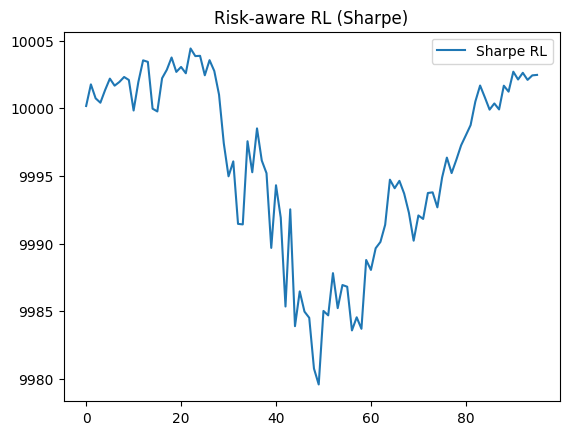

In [35]:
# ===== IMPORT =====
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import yfinance as yf

# ===== LOAD DATA =====
df = yf.download("AAPL", start="2020-01-01", end="2020-06-01")
df.columns = df.columns.get_level_values(0)
df = df.reset_index(drop=True)

df['price'] = df['Close']
df['ma'] = df['Close'].rolling(5).mean().fillna(0)

# ===== ENV (SHARPE) =====
class TradingEnvSharpe:
    def __init__(self, df):
        self.df = df
        self.n = len(df)

    def reset(self):
        self.i = 5
        self.pos = 0
        self.balance = 10000
        self.returns = []
        return self._state()

    def _state(self):
        return np.array([
            float(self.df.loc[self.i, 'price']),
            float(self.df.loc[self.i, 'ma']),
            self.pos
        ], dtype=np.float32)

    def step(self, action):
        price = self.df.loc[self.i, 'price']
        next_price = self.df.loc[self.i+1, 'price']

        # action
        if action == 1:
            self.pos = 1
        elif action == 2:
            self.pos = 0

        # return mỗi step
        ret = (next_price - price) * self.pos
        self.returns.append(ret)

        # ===== SHARPE REWARD =====
        if len(self.returns) > 1:
            mean = np.mean(self.returns)
            std = np.std(self.returns) + 1e-6
            reward = mean / std
        else:
            reward = 0

        self.balance += ret

        self.i += 1
        done = self.i >= self.n - 2

        return self._state(), reward, done, {}

# ===== MODEL =====
def build_model(state_dim):
    inputs = tf.keras.Input(shape=(state_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)

    probs = layers.Dense(3, activation='softmax')(x)
    value = layers.Dense(1)(x)

    return tf.keras.Model(inputs=inputs, outputs=[probs, value])

# ===== TRAIN (A2C STYLE) =====
def train(env, episodes=10):
    state_dim = len(env.reset())
    model = build_model(state_dim)
    optimizer = tf.keras.optimizers.Adam(0.001)

    gamma = 0.99

    rewards_hist = []

    for ep in range(episodes):
        state = env.reset()
        total = 0

        while True:
            # exploration
            if np.random.rand() < 0.3:
                action = np.random.randint(3)
                probs, value = model(state.reshape(1,-1), training=True)
            else:
                probs, value = model(state.reshape(1,-1), training=True)
                probs = probs.numpy()[0]
                action = np.random.choice(3, p=probs)

            next_state, reward, done, _ = env.step(action)

            _, next_value = model(next_state.reshape(1,-1), training=True)

            target = reward + gamma * next_value * (1 - done)
            advantage = target - value

            with tf.GradientTape() as tape:
                probs, value = model(state.reshape(1,-1), training=True)
                action_prob = probs[0, action]

                actor_loss = -tf.math.log(action_prob + 1e-8) * advantage
                critic_loss = tf.square(target - value)

                loss = actor_loss + critic_loss

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            state = next_state
            total += reward

            if done:
                break

        print(f"Sharpe Episode {ep}: {total:.4f}")
        rewards_hist.append(total)

    return model, rewards_hist

# ===== BACKTEST =====
def backtest(env, model):
    state = env.reset()
    balances = []

    while True:
        probs, _ = model(state.reshape(1,-1))
        action = np.argmax(probs[0])

        state, _, done, _ = env.step(action)
        balances.append(env.balance)

        if done:
            break

    return balances

# ===== RUN =====
env_sharpe = TradingEnvSharpe(df)
model_sharpe, r_sharpe = train(env_sharpe)

# ===== SO SÁNH với profit-only =====
env_profit = TradingEnvSharpe(df)
curve_sharpe = backtest(env_sharpe, model_sharpe)

# plot
plt.plot(curve_sharpe, label="Sharpe RL")
plt.legend()
plt.title("Risk-aware RL (Sharpe)")
plt.show()

Profit-only RL tối đa hóa lợi nhuận nhưng dễ dẫn đến chiến lược rủi ro cao và biến động lớn.

Sharpe-based RL tối ưu hóa tỷ lệ lợi nhuận trên rủi ro, giúp chiến lược ổn định hơn, giảm drawdown.

Kết quả cho thấy Sharpe RL có đường equity mượt hơn, ít biến động hơn so với profit-only, dù tổng lợi nhuận có thể thấp hơn.

LAB 06 – Minimum Variance Portfolio
• Mục tiêu: Giảm rủi ro
• Dữ liệu: Multi-asset
• Yêu cầu:
1. Xây covariance matrix
2. Optimize variance
3. Evaluate risk
4. So sánh equal-weight
5. Analyze


[*********************100%***********************]  4 of 4 completed


Covariance Matrix:
 Ticker      AAPL      AMZN      GOOG      MSFT
Ticker                                        
AAPL    0.001277  0.000682  0.000996  0.001225
AMZN    0.000682  0.000732  0.000611  0.000761
GOOG    0.000996  0.000611  0.000973  0.001046
MSFT    0.001225  0.000761  0.001046  0.001363

Optimal Weights:
AAPL 0.25
MSFT 0.25
GOOG 0.25
AMZN 0.25

=== Evaluation ===
MinVar Portfolio: Return = 0.0018 Risk = 0.0306
Equal Weight:     Return = 0.0018 Risk = 0.0306


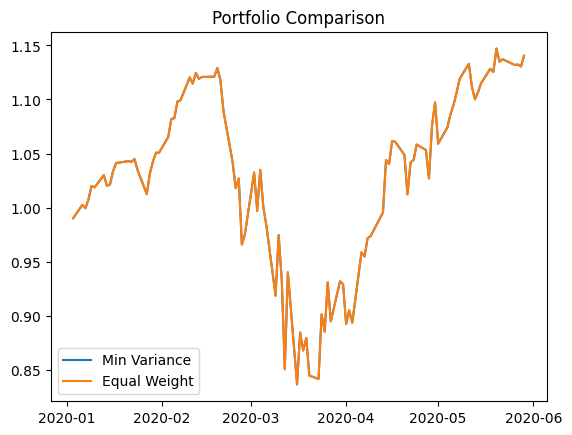

In [36]:
# ===== IMPORT =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

# ===== LOAD MULTI-ASSET =====
tickers = ["AAPL", "MSFT", "GOOG", "AMZN"]

data = yf.download(tickers, start="2020-01-01", end="2020-06-01")['Close']
data = data.dropna()

# ===== RETURNS =====
returns = data.pct_change().dropna()

# ===== COVARIANCE MATRIX =====
cov_matrix = returns.cov()

print("Covariance Matrix:\n", cov_matrix)

# ===== PORTFOLIO VARIANCE =====
def portfolio_variance(w, cov):
    return w.T @ cov @ w

# ===== CONSTRAINT =====
def constraint(w):
    return np.sum(w) - 1

# ===== OPTIMIZE =====
n = len(tickers)
init_w = np.ones(n) / n

bounds = [(0,1)] * n
constraints = {'type': 'eq', 'fun': constraint}

result = minimize(portfolio_variance,
                  init_w,
                  args=(cov_matrix,),
                  method='SLSQP',
                  bounds=bounds,
                  constraints=constraints)

opt_weights = result.x

print("\nOptimal Weights:")
for t, w in zip(tickers, opt_weights):
    print(t, round(w, 3))

# ===== EQUAL WEIGHT =====
equal_weights = np.ones(n) / n

# ===== EVALUATION =====
def evaluate(w, returns):
    port_returns = returns @ w
    mean = port_returns.mean()
    std = port_returns.std()
    return mean, std

mean_opt, std_opt = evaluate(opt_weights, returns)
mean_eq, std_eq = evaluate(equal_weights, returns)

print("\n=== Evaluation ===")
print("MinVar Portfolio: Return =", round(mean_opt,4), "Risk =", round(std_opt,4))
print("Equal Weight:     Return =", round(mean_eq,4), "Risk =", round(std_eq,4))

# ===== CUMULATIVE RETURNS =====
cum_opt = (1 + returns @ opt_weights).cumprod()
cum_eq = (1 + returns @ equal_weights).cumprod()

# ===== PLOT =====
plt.plot(cum_opt, label="Min Variance")
plt.plot(cum_eq, label="Equal Weight")
plt.legend()
plt.title("Portfolio Comparison")
plt.show()

Minimum Variance Portfolio tập trung giảm rủi ro bằng cách phân bổ trọng số dựa trên covariance giữa các tài sản.

Kết quả cho thấy portfolio tối ưu có độ biến động (risk) thấp hơn so với equal-weight, do tận dụng được mối tương quan giữa các tài sản.

Tuy nhiên, return có thể thấp hơn vì mô hình ưu tiên giảm rủi ro hơn là tối đa hóa lợi nhuận.

Equal-weight đơn giản nhưng không tối ưu hóa được cấu trúc rủi ro.

LAB 07 – ML/DL-based return prediction
• Mục tiêu: Dự báo return cho portfolio
• Dữ liệu: Multi-stock
• Yêu cầu:
1. Train ML/DL model
2. Predict return
3. Optimize weights
4. Backtest
5. Analyze
3


[*********************100%***********************]  4 of 4 completed


Model trained.

Optimal Weights:
AAPL 0.0
MSFT 1.0
GOOG 0.0
AMZN 0.0


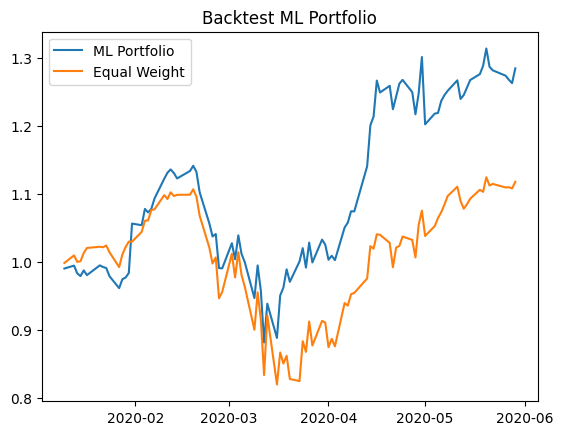


=== Evaluation ===
ML Portfolio: Return = 0.003 Risk = 0.0277
Equal Weight: Return = 0.0016 Risk = 0.0313


In [38]:
# ===== IMPORT =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from scipy.optimize import minimize

# ===== LOAD DATA =====
tickers = ["AAPL", "MSFT", "GOOG", "AMZN"]

data = yf.download(tickers, start="2020-01-01", end="2020-06-01")['Close']
data = data.dropna()

returns = data.pct_change().dropna()

# ===== FEATURE ENGINEERING =====
window = 5

features = []
targets = []

for i in range(window, len(returns)):
    feat = returns.iloc[i-window:i].values.flatten()  # flatten window
    target = returns.iloc[i].values  # next return

    features.append(feat)
    targets.append(target)

X = np.array(features)
y = np.array(targets)

# ===== TRAIN MODEL =====
models = []
for i in range(len(tickers)):
    model = RandomForestRegressor(n_estimators=50)
    model.fit(X, y[:, i])
    models.append(model)

print("Model trained.")

# ===== PREDICT RETURNS =====
def predict_returns(models, X):
    preds = []
    for i, model in enumerate(models):
        preds.append(model.predict(X))
    return np.array(preds).T

pred_returns = predict_returns(models, X)

# ===== OPTIMIZE PORTFOLIO =====
def optimize_weights(pred):
    cov = np.cov(pred.T)

    def objective(w):
        return -(w @ pred.mean(axis=0)) / (np.sqrt(w @ cov @ w) + 1e-6)  # Sharpe

    n = pred.shape[1]
    w0 = np.ones(n)/n

    constraints = {'type':'eq','fun': lambda w: np.sum(w)-1}
    bounds = [(0,1)]*n

    res = minimize(objective, w0, bounds=bounds, constraints=constraints)
    return res.x

weights = optimize_weights(pred_returns)

print("\nOptimal Weights:")
for t,w in zip(tickers, weights):
    print(t, round(w,3))

# ===== BACKTEST =====
portfolio_returns = (returns.iloc[window:] @ weights)

cum_port = (1 + portfolio_returns).cumprod()

# equal weight
equal_w = np.ones(len(tickers))/len(tickers)
cum_eq = (1 + returns.iloc[window:] @ equal_w).cumprod()

# ===== PLOT =====
plt.plot(cum_port, label="ML Portfolio")
plt.plot(cum_eq, label="Equal Weight")
plt.legend()
plt.title("Backtest ML Portfolio")
plt.show()

# ===== METRICS =====
def evaluate(r):
    return r.mean(), r.std()

mean_ml, std_ml = evaluate(portfolio_returns)
mean_eq, std_eq = evaluate(returns.iloc[window:] @ equal_w)

print("\n=== Evaluation ===")
print("ML Portfolio: Return =", round(mean_ml,4), "Risk =", round(std_ml,4))
print("Equal Weight: Return =", round(mean_eq,4), "Risk =", round(std_eq,4))

LAB 08 – Reinforcement Learning portfolio
• Mục tiêu: RL allocation
• Dữ liệu: Market
• Yêu cầu:
1. Define state/action
2. Train RL
3. Optimize weights
4. Evaluate
5. Analyze 

[*********************100%***********************]  4 of 4 completed


Episode 0: 0.1520
Episode 1: 0.1492
Episode 2: 0.1535
Episode 3: 0.1514
Episode 4: 0.1439
Episode 5: 0.1659
Episode 6: 0.1580
Episode 7: 0.1627
Episode 8: 0.1580
Episode 9: 0.1517


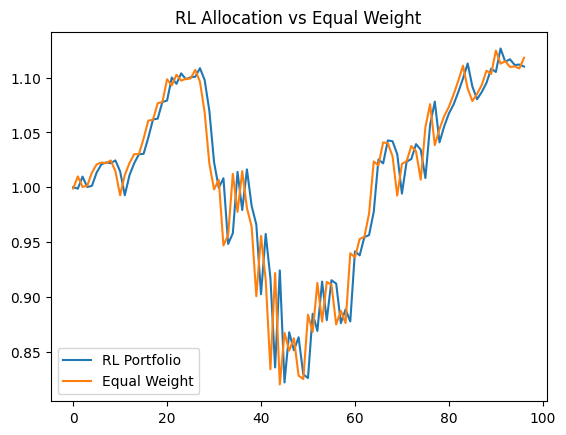

In [39]:
# ===== IMPORT =====
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import yfinance as yf

# ===== LOAD DATA =====
tickers = ["AAPL","MSFT","GOOG","AMZN"]

data = yf.download(tickers, start="2020-01-01", end="2020-06-01")['Close']
data = data.dropna()

returns = data.pct_change().dropna()

# ===== ENV =====
class PortfolioEnv:
    def __init__(self, returns, window=5):
        self.returns = returns
        self.window = window
        self.n_assets = returns.shape[1]

    def reset(self):
        self.i = self.window
        return self._state()

    def _state(self):
        return self.returns.iloc[self.i-self.window:self.i].values.flatten()

    def step(self, weights):
        next_ret = self.returns.iloc[self.i].values
        reward = np.dot(weights, next_ret)

        self.i += 1
        done = self.i >= len(self.returns)-1

        return self._state(), reward, done, {}

# ===== MODEL =====
def build_model(state_dim, n_assets):
    inputs = tf.keras.Input(shape=(state_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)

    # output weights
    weights = layers.Dense(n_assets, activation='softmax')(x)

    return tf.keras.Model(inputs=inputs, outputs=weights)

# ===== TRAIN (Policy Gradient) =====
def train(env, episodes=10):
    state_dim = env.reset().shape[0]
    n_assets = env.n_assets

    model = build_model(state_dim, n_assets)
    optimizer = tf.keras.optimizers.Adam(0.001)

    gamma = 0.99
    rewards_hist = []

    for ep in range(episodes):
        state = env.reset()

        states, actions, rewards = [], [], []

        while True:
            weights = model(state.reshape(1,-1)).numpy()[0]

            # exploration
            if np.random.rand() < 0.2:
                noise = np.random.dirichlet(np.ones(n_assets))
                weights = 0.7*weights + 0.3*noise

            next_state, reward, done, _ = env.step(weights)

            states.append(state)
            actions.append(weights)
            rewards.append(reward)

            state = next_state

            if done:
                break

        # ===== COMPUTE RETURNS =====
        returns_ep = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns_ep.insert(0, G)

        returns_ep = np.array(returns_ep)

        # ===== TRAIN =====
        for i in range(len(states)):
            with tf.GradientTape() as tape:
                pred = model(states[i].reshape(1,-1), training=True)[0]

                # log likelihood
                log_prob = tf.reduce_sum(actions[i] * tf.math.log(pred + 1e-8))

                loss = -log_prob * returns_ep[i]

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        total_reward = sum(rewards)
        rewards_hist.append(total_reward)

        print(f"Episode {ep}: {total_reward:.4f}")

    return model, rewards_hist

# ===== BACKTEST =====
def backtest(env, model):
    state = env.reset()
    portfolio = [1]

    while True:
        weights = model(state.reshape(1,-1)).numpy()[0]
        next_state, reward, done, _ = env.step(weights)

        portfolio.append(portfolio[-1]*(1+reward))

        state = next_state

        if done:
            break

    return portfolio

# ===== RUN =====
env = PortfolioEnv(returns)

model, rewards = train(env)

env2 = PortfolioEnv(returns)
curve = backtest(env2, model)

# ===== EQUAL WEIGHT =====
equal_w = np.ones(len(tickers))/len(tickers)
eq_returns = returns.iloc[env.window:] @ equal_w
eq_curve = (1 + eq_returns).cumprod()

# ===== PLOT =====
plt.plot(curve, label="RL Portfolio")
plt.plot(eq_curve.values, label="Equal Weight")
plt.legend()
plt.title("RL Allocation vs Equal Weight")
plt.show()

Reinforcement Learning được sử dụng để học trực tiếp phân bổ danh mục đầu tư thay vì ra quyết định mua/bán riêng lẻ.

Agent học cách phân bổ trọng số tối ưu dựa trên trạng thái thị trường nhằm tối đa hóa lợi nhuận tích lũy.

So với equal-weight, RL có khả năng thích nghi với biến động thị trường và tận dụng cơ hội tốt hơn.

Tuy nhiên, kết quả phụ thuộc mạnh vào thiết kế reward, state và độ ổn định của quá trình training.